# Customer Segmentation using K-Means Clustering

## Objective
The goal of this project is to segment customers based on their annual income and spending behavior using the K-Means clustering algorithm.

## Project Overview

Customer segmentation is the process of dividing customers into groups based on their behavior and characteristics. In this project, K-Means Clustering is used to segment customers based on their Annual Income and Spending Score. This helps businesses understand customer behavior and develop targeted marketing strategies.

## Dataset Description

The dataset contains customer information collected from a shopping mall. It includes demographic and spending-related features that can be used for customer segmentation.

Features:
- CustomerID
- Gender
- Age
- Annual Income (k$)
- Spending Score (1-100)

Total Records: 200

## Importing Libraries and Loading Dataset

In [1]:
import pandas as pd

df = pd.read_csv('/content/archive (4).zip')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Information

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Dataset Summary

In [14]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 200
Columns: 6


## Missing Values Analysis

In [3]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


## Feature Selection

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


## Applying K-Means Clustering

In [5]:
from sklearn.cluster import KMeans

In [6]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

print(wcss)

[269981.28000000014, 183653.3289473683, 106348.37306211119, 73880.64496247198, 44448.45544793369, 40825.16946386947, 33642.57922077922, 26686.837785187785, 24766.471609793436, 23103.122085983905]


## Finding the Optimal Number of Clusters using Elbow Method

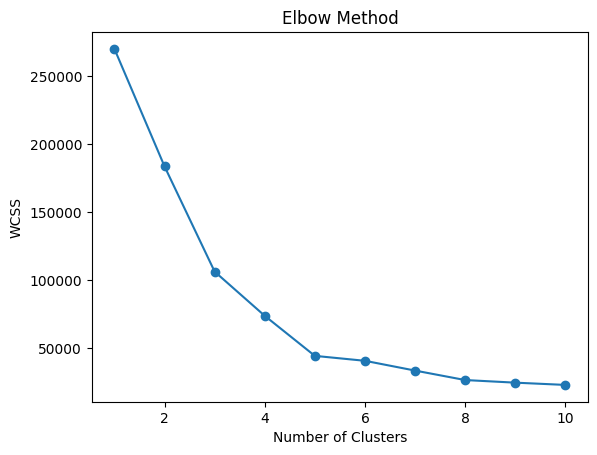

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## Building the K-Means Clustering Model

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42)

y_kmeans = kmeans.fit_predict(X)

print(y_kmeans)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


## Customer Segmentation Visualization

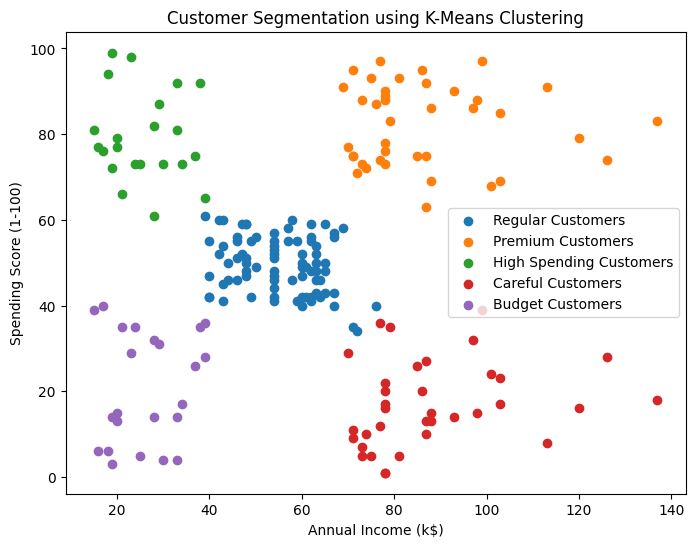

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans==0]['Annual Income (k$)'],
            X[y_kmeans==0]['Spending Score (1-100)'],
            label='Regular Customers')

plt.scatter(X[y_kmeans==1]['Annual Income (k$)'],
            X[y_kmeans==1]['Spending Score (1-100)'],
            label='Premium Customers')

plt.scatter(X[y_kmeans==2]['Annual Income (k$)'],
            X[y_kmeans==2]['Spending Score (1-100)'],
            label='High Spending Customers')

plt.scatter(X[y_kmeans==3]['Annual Income (k$)'],
            X[y_kmeans==3]['Spending Score (1-100)'],
            label='Careful Customers')

plt.scatter(X[y_kmeans==4]['Annual Income (k$)'],
            X[y_kmeans==4]['Spending Score (1-100)'],
            label='Budget Customers')

plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.savefig('customer_segmentation.png', bbox_inches='tight')
plt.show()

## Number of Customers in Each Segment

In [15]:
df['Cluster'] = y_kmeans

df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


## Cluster Centers

In [16]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Annual Income (k$)', 'Spending Score (1-100)']
)

centers

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Customer Segment Insights

Based on the clustering results, five customer segments were identified:

- Premium Customers: High Income and High Spending
- Careful Customers: High Income and Low Spending
- High Spending Customers: Low Income and High Spending
- Budget Customers: Low Income and Low Spending
- Regular Customers: Average Income and Average Spending

These customer segments can help businesses create targeted marketing strategies and improve customer engagement.

## Conclusion

This project successfully segmented customers into five distinct groups using K-Means Clustering based on Annual Income and Spending Score. The optimal number of clusters was determined using the Elbow Method. The identified customer segments can help businesses understand customer behavior, improve marketing strategies, and make better business decisions.